# Bank Loan Risk Prediction
## Predicting Bad Loans Among Current Borrowers

**Goal:** Train on completed loans (Fully Paid / Charged Off), then predict which Current loans are likely to go bad.

**Models:** Logistic Regression · LightGBM · CatBoost

**Metric:** AUC-ROC — not accuracy (data is 86/14 imbalanced)

In [1]:
!pip install lightgbm
!pip install catboost
!pip install shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import shap

# Step 2: Load and Explore Data


In [10]:
df = pd.read_csv("financial_loan_clean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             38576 non-null  int64  
 1   id                     38576 non-null  int64  
 2   address_state          38576 non-null  object 
 3   application_type       38576 non-null  object 
 4   emp_length             38576 non-null  object 
 5   emp_title              37138 non-null  object 
 6   grade                  38576 non-null  object 
 7   home_ownership         38576 non-null  object 
 8   issue_date             38576 non-null  object 
 9   last_credit_pull_date  38576 non-null  object 
 10  last_payment_date      38576 non-null  object 
 11  loan_status            38576 non-null  object 
 12  next_payment_date      38576 non-null  object 
 13  member_id              38576 non-null  int64  
 14  purpose                38576 non-null  object 
 15  su

In [9]:
print(f'Shape: {df.shape}')
print(f'\nloan_status distribution:')
print(df['loan_status'].value_counts())
print(f'\nPercentage:')
print((df['loan_status'].value_counts(normalize=True)*100).round(1))

Shape: (38576, 26)

loan_status distribution:
loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64

Percentage:
loan_status
Fully Paid     83.3
Charged Off    13.8
Current         2.8
Name: proportion, dtype: float64


## Step 3 — Create Label & Split Dataset

- **Training set** = Fully Paid + Charged Off (completed loans — outcome known)
- **Prediction set** = Current loans (outcome unknown — what we predict)
- **Label:** Charged Off = 1 (Bad Loan), Fully Paid = 0 (Good Loan)

In [ ]:
df_train = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df_current = df[df['loan_status'] == 'Current'].copy()

df_train['is_bad_loan'] = (df_train['loan_status'] == 'Charged Off').astype(int)

In [12]:
print(f'Training set : {len(df_train):,} rows')
print(f'Current loans: {len(df_current):,} rows (prediction set)')
print(f'\nLabel distribution:')
print(df_train['is_bad_loan'].value_counts())
print(f'\nBad loan rate: {df_train["is_bad_loan"].mean()*100:.1f}%')

Training set : 37,478 rows
Current loans: 1,098 rows (prediction set)

Label distribution:
is_bad_loan
0    32145
1     5333
Name: count, dtype: int64

Bad loan rate: 14.2%


## Step 4 — Define Features

Only columns known at **application time** — no data leakage.

**Excluded:**
- `total_payment` — only exists after loan resolves (leaks outcome)
- `last_payment_date`, `next_payment_date`, `last_credit_pull_date` — post-loan info
- `emp_title` — 1,438 missing, too noisy
- `id`, `member_id`, `Unnamed: 0` — identifiers
- `issue_date`, `month` — would need extra date engineering

In [18]:
FEATURES = [
    'loan_amount',
    'int_rate',
    'installment',
    'annual_income',
    'dti',
    'total_acc',
    'grade',
    'sub_grade',
    'term',
    'home_ownership',
    'purpose',
    'verification_status',
    'address_state',
    'application_type',
    'emp_length',
]

# Use pd.api.types for reliable dtype detection (newer pandas uses StringDtype)
cat_cols = [f for f in FEATURES if pd.api.types.is_string_dtype(df_train[f])]
num_cols = [f for f in FEATURES if not pd.api.types.is_string_dtype(df_train[f])]

In [19]:
print(f'Total features  : {len(FEATURES)}')
print(f'Numeric columns : {num_cols}')
print(f'Categorical cols: {cat_cols}')

Total features  : 15
Numeric columns : ['loan_amount', 'int_rate', 'installment', 'annual_income', 'dti', 'total_acc']
Categorical cols: ['grade', 'sub_grade', 'term', 'home_ownership', 'purpose', 'verification_status', 'address_state', 'application_type', 'emp_length']


## Step 5 — Encode Categorical Columns

Convert text columns into numbers using Label Encoding.
We fit on training data only, then reuse the same mapping for Current loans.
Final output is a NumPy array to avoid dtype issues with sklearn.

In [21]:
encoders = {}

def encode_features(df_input, fit=False):
    df_enc = df_input[FEATURES].copy()
    # Encode categorical columns
    for col in cat_cols:
        if fit:   #fit = True (called on Training data)
            le = LabelEncoder()
            df_enc[col] = le.fit_transform(df_enc[col].astype(str))
            encoders[col] = le
        else:    # fit = False (called on current data)
            le = encoders[col]
            df_enc[col] = df_enc[col].astype(str).apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
    # Convert all to numeric and return as numpy array
    return df_enc.astype(float).values  

In [22]:
X_all = encode_features(df_train, fit= True)
y_all = df_train['is_bad_loan'].values

print(f'Feature matrix shape : {X_all.shape}')
print(f'Feature matrix dtype : {X_all.dtype}')
print('Encoding complete — all values are numeric')

Feature matrix shape : (37478, 15)
Feature matrix dtype : float64
Encoding complete — all values are numeric


## Step 6 — Train / Test Split

80% train, 20% test.
`stratify=y_all` keeps the same 86/14 ratio in both splits — important for imbalanced data.

In [24]:
X_train,X_test, y_train, y_test = train_test_split(X_all, y_all, stratify = y_all, random_state = 42, test_size = 0.2)

In [25]:
print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test : {X_test.shape[0]:,} rows')
print(f'\nBad loan rate — train: {y_train.mean()*100:.1f}%')
print(f'Bad loan rate — test : {y_test.mean()*100:.1f}%')

Train: 29,982 rows
Test : 7,496 rows

Bad loan rate — train: 14.2%
Bad loan rate — test : 14.2%


## Step 7 — Train 3 Models

- **Logistic Regression** — simple linear baseline
- **LightGBM** — fast gradient boosting by Microsoft
- **CatBoost** — gradient boosting by Yandex, great with categorical data

`class_weight='balanced'` / `is_unbalance=True` handles the 86/14 imbalance automatically.

In [30]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
print('Logistic Regression — trained')

# Model 2: LightGBM
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train)
print('LightGBM           — trained')

# Model 3: CatBoost
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train)
print('CatBoost           — trained')

Logistic Regression — trained
LightGBM           — trained
CatBoost           — trained


## Step 8 — Evaluate All 3 Models

AUC-ROC interpretation:
- **1.0** = perfect | **0.5** = unsatisfied | **>0.70** = good (per the research paper)

In [31]:
def evaluate_model(model, name, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]     #probability of Positive class (here is Bad Loan)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_prob)
    print(f'\n' + '='*45)
    print(f'  {name}  |  AUC-ROC: {auc:.4f}')
    print('='*45)
    print(classification_report(y_test, y_pred, target_names=['Good Loan', 'Bad Loan']))
    return auc, y_prob

In [34]:
auc_lr,   prob_lr   = evaluate_model(lr,   'Logistic Regression', X_test, y_test)
auc_lgbm, prob_lgbm = evaluate_model(lgbm, 'LightGBM',           X_test, y_test)
auc_cat,  prob_cat  = evaluate_model(cat,  'CatBoost',           X_test, y_test)


  Logistic Regression  |  AUC-ROC: 0.6752
              precision    recall  f1-score   support

   Good Loan       0.91      0.64      0.75      6429
    Bad Loan       0.22      0.63      0.33      1067

    accuracy                           0.64      7496
   macro avg       0.57      0.63      0.54      7496
weighted avg       0.81      0.64      0.69      7496


  LightGBM  |  AUC-ROC: 0.6907
              precision    recall  f1-score   support

   Good Loan       0.91      0.71      0.79      6429
    Bad Loan       0.24      0.56      0.33      1067

    accuracy                           0.68      7496
   macro avg       0.57      0.63      0.56      7496
weighted avg       0.81      0.68      0.73      7496


  CatBoost  |  AUC-ROC: 0.6966
              precision    recall  f1-score   support

   Good Loan       0.92      0.65      0.76      6429
    Bad Loan       0.23      0.64      0.34      1067

    accuracy                           0.65      7496
   macro avg       0.

## Step 9 — 5-Fold Cross-Validation

More reliable than a single 80/20 split.
The model trains 5 times on different data slices — gives a stable AUC estimate.

In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Running cross-validation (this may take a minute)...')
cv_lr   = cross_val_score(lr,   X_all, y_all, cv=cv, scoring='roc_auc')
cv_lgbm = cross_val_score(lgbm, X_all, y_all, cv=cv, scoring='roc_auc')
cv_cat  = cross_val_score(cat,  X_all, y_all, cv=cv, scoring='roc_auc')

results = pd.DataFrame({
    'Model':       ['Logistic Regression', 'LightGBM', 'CatBoost'],
    'Test AUC':    [round(auc_lr,4), round(auc_lgbm,4), round(auc_cat,4)],
    'CV AUC Mean': [round(cv_lr.mean(),4), round(cv_lgbm.mean(),4), round(cv_cat.mean(),4)],
    'CV AUC Std':  [round(cv_lr.std(),4),  round(cv_lgbm.std(),4),  round(cv_cat.std(),4)],
})

print(results)
best_name = results.loc[results['CV AUC Mean'].idxmax(), 'Model']
print(f'\nBest model: {best_name}')

Running cross-validation (this may take a minute)...
                 Model  Test AUC  CV AUC Mean  CV AUC Std
0  Logistic Regression    0.6752       0.6863      0.0049
1             LightGBM    0.6907       0.6974      0.0076
2             CatBoost    0.6966       0.7048      0.0071

Best model: CatBoost


## Step 10 — Model Comparison Chart

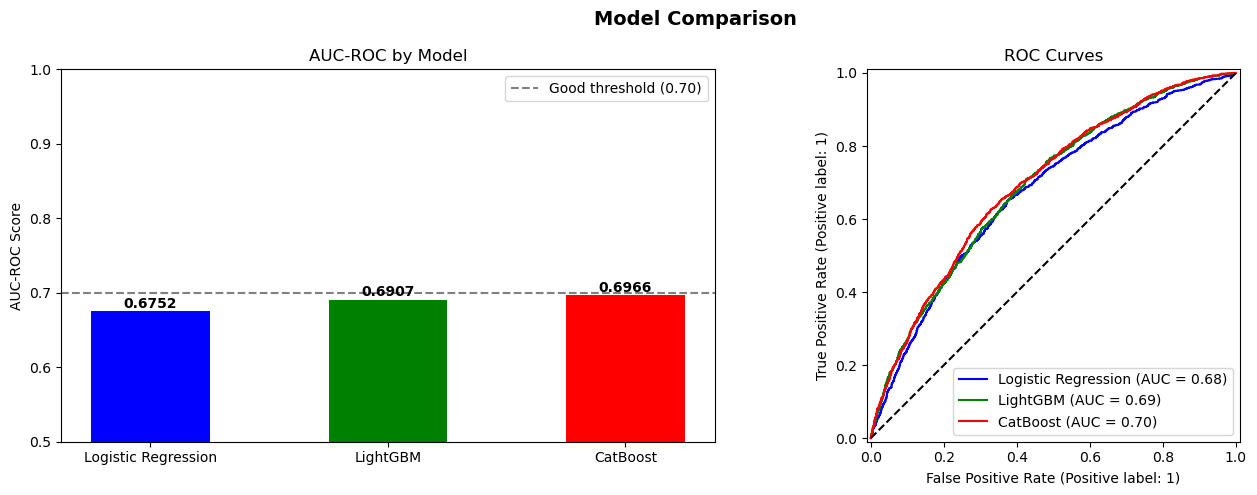

Saved: model_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

# AUC bar chart
model_names = ['Logistic Regression', 'LightGBM', 'CatBoost']
aucs = [auc_lr, auc_lgbm, auc_cat]
colors = ['b', 'g', 'r']
bars = axes[0].bar(model_names, aucs, color=colors, width=0.5)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('AUC-ROC by Model')
axes[0].set_ylabel('AUC-ROC Score')
axes[0].axhline(0.7, color='gray', linestyle='--', label='Good threshold (0.70)')
axes[0].legend()
for bar, auc in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{auc:.4f}', ha='center', fontweight='bold')

# ROC curves
for name, prob, color in zip(
    ['Logistic Regression', 'LightGBM', 'CatBoost'],
    [prob_lr, prob_lgbm, prob_cat],
    ['b', 'g', 'r']
):
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[1], color=color)  #internally compute FPR and TPR and plot ROC curve
axes[1].plot([0,1],[0,1], 'k--', label='Random guess')
axes[1].set_title('ROC Curves')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

# Step 11: Chose & Tune Parameters

In [43]:
!pip install optuna

In [42]:
import optuna
import catboost as cb


def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 700),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.05, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.05, 1.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 2, 100),
        "auto_class_weights": "Balanced",  # keep imbalance handling
        "random_seed": 42,
    }

    model = cb.CatBoostClassifier(**params, silent=True)
    model.fit(X_train, y_train)

    # Use predict_proba + AUC instead of predict + accuracy
    prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, prob)
    return auc

study = optuna.create_study(direction="maximize")  # maximize AUC
study.optimize(objective, n_trials=100)

print(f"Number of finished trials: {len(study.trials)}")
print(f"\nBest trial:")
print(f"  AUC : {study.best_trial.value:.4f}")
print(f"  Params:")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-07-31 11:15:52,581] A new study created in memory with name: no-name-b6a00d6a-8b43-4f7b-bec2-d0368f19c151
[I 2026-07-31 11:15:53,755] Trial 0 finished with value: 0.6920482297951979 and parameters: {'iterations': 247, 'learning_rate': 0.08121363121197753, 'depth': 4, 'subsample': 0.08240626837819126, 'colsample_bylevel': 0.0535328637178386, 'min_data_in_leaf': 38}. Best is trial 0 with value: 0.6920482297951979.
[I 2026-07-31 11:15:58,428] Trial 1 finished with value: 0.6904375280531647 and parameters: {'iterations': 250, 'learning_rate': 0.0352523558893373, 'depth': 9, 'subsample': 0.6836728629483684, 'colsample_bylevel': 0.864878258607009, 'min_data_in_leaf': 62}. Best is trial 0 with value: 0.6920482297951979.
[I 2026-07-31 11:16:01,168] Trial 2 finished with value: 0.6793728278158526 and parameters: {'iterations': 650, 'learning_rate': 0.0013475832340886884, 'depth': 1, 'subsample': 0.744784332875468, 'colsample_bylevel': 0.23509302573196528, 'min_data_in_leaf': 59}. Best i

Number of finished trials: 100

Best trial:
  AUC : 0.6999
  Params:
    iterations: 352
    learning_rate: 0.035503970129075926
    depth: 6
    subsample: 0.5199790794521953
    colsample_bylevel: 0.2576975353576756
    min_data_in_leaf: 21


## Step 12 — SHAP: Why Does the Model Predict Bad Loan?

SHAP shows **how much each feature pushed** a prediction toward good or bad.
- **Red** = pushes toward Bad Loan
- **Blue** = pushes toward Good Loan
- **Width** = how many loans have that feature value

This connects the model back to the original Segment A/B/C analysis.

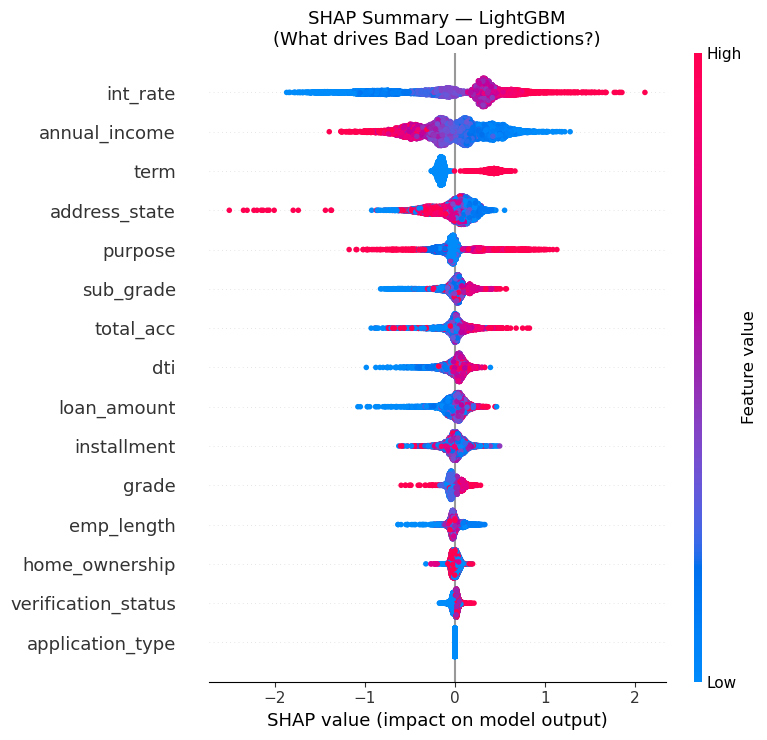

Saved: shap_summary.png


In [39]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

# For binary classification shap_values may be a list — take class 1 (bad loan)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Summary — LightGBM\n(What drives Bad Loan predictions?)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_summary.png')

## Step 13 - Train Best Model with Chosed Parameters
- Apply the best model to all 1,098 Current loans.
- Output: a risk probability (0–1) for each loan, ranked highest risk first.

In [46]:
# Get best parameters from Optuna
best_params = study.best_trial.params

# Add fixed parameters that weren't tuned
best_params["auto_class_weights"] = "Balanced"
best_params["random_seed"] = 42

print("Best parameters found:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

Best parameters found:
  iterations: 352
  learning_rate: 0.035503970129075926
  depth: 6
  subsample: 0.5199790794521953
  colsample_bylevel: 0.2576975353576756
  min_data_in_leaf: 21
  auto_class_weights: Balanced
  random_seed: 42


In [ ]:
# Train final CatBoost with best parameters
best_cat = cb.CatBoostClassifier(**best_params, silent=True)
best_cat.fit(X_train, y_train)


Final CatBoost model trained


In [48]:
prob_best = best_cat.predict_proba(X_test)[:,1]
auc_best =roc_auc_score(y_test, prob_best)

print(f"Original CatBoost AUC : {auc_cat:.4f}")
print(f"Optimized CatBoost AUC: {auc_best:.4f}")
print(f"Improvement           : +{(auc_best - auc_cat):.4f}")

Original CatBoost AUC : 0.6966
Optimized CatBoost AUC: 0.6999
Improvement           : +0.0033


### Predict on Current Loan

In [50]:
# Encode Current loans using same encoders
X_current = encode_features(df_current, fit=False)

# Predict risk probability
risk_probs = best_cat.predict_proba(X_current)[:, 1]

#Add prediction to current loan dataframe
df_current = df_current.copy()
df_current['bad_loan_probability'] = risk_probs
df_current['risk_label'] = pd.cut(
    risk_probs,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df_results = df_current.sort_values('bad_loan_probability', ascending=False)

print('\nRisk distribution of Current loans:')
print(df_results['risk_label'].value_counts())
high_risk = df_results[df_results['risk_label'] == 'High Risk']
print(f'\nHigh Risk loans    : {len(high_risk)}')
print(f'Loan amount at risk: ${high_risk["loan_amount"].sum():,.0f}')


Risk distribution of Current loans:
risk_label
High Risk      705
Medium Risk    385
Low Risk         8
Name: count, dtype: int64

High Risk loans    : 705
Loan amount at risk: $11,853,100


# Step 14: Visualize Current Loan Risk

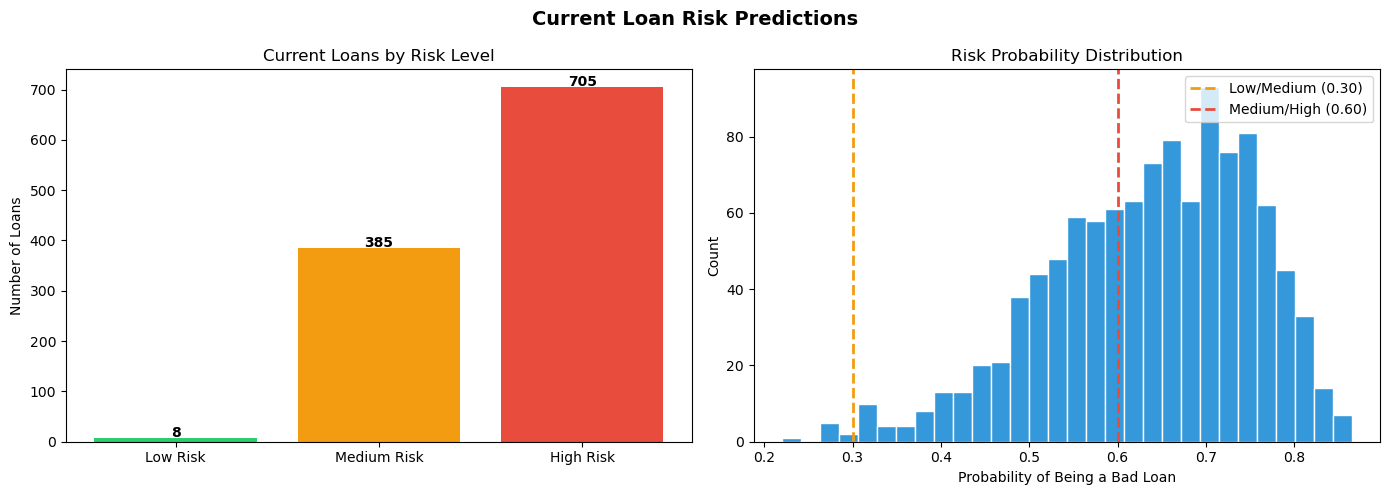

Saved: current_loan_risk.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Current Loan Risk Predictions', fontsize=14, fontweight='bold')

# Risk label chart
risk_counts = df_results['risk_label'].value_counts().reindex(['Low Risk','Medium Risk','High Risk'])
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(risk_counts.index, risk_counts.values, color=colors)
axes[0].set_title('Current Loans by Risk Level')
axes[0].set_ylabel('Number of Loans')
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold')

# Probability histogram
axes[1].hist(risk_probs, bins=30, color='#3498db', edgecolor='white')
axes[1].axvline(0.3, color='#f39c12', linestyle='--', linewidth=2, label='Low/Medium (0.30)')
axes[1].axvline(0.6, color='#e74c3c', linestyle='--', linewidth=2, label='Medium/High (0.60)')
axes[1].set_title('Risk Probability Distribution')
axes[1].set_xlabel('Probability of Being a Bad Loan')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('current_loan_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: current_loan_risk.png')

# Step 15: Export to CSV

In [52]:
print('Top 10 Highest-Risk Current Loans:')
print(df_results[['loan_amount','grade','purpose','int_rate',
                   'bad_loan_probability','risk_label']].head(10).to_string(index=False))

df_results.to_csv('current_loan_risk_predictions.csv', index=False)
print(f'\nSaved: current_loan_risk_predictions.csv ({len(df_results):,} rows)')

Top 10 Highest-Risk Current Loans:
 loan_amount grade            purpose  int_rate  bad_loan_probability risk_label
       15250     F Debt consolidation    0.2089              0.864595  High Risk
        6400     F     small business    0.2294              0.858785  High Risk
        9375     F Debt consolidation    0.2167              0.856172  High Risk
       24000     F     small business    0.2206              0.855776  High Risk
        6700     C     small business    0.1527              0.855172  High Risk
       18250     G Debt consolidation    0.2352              0.855110  High Risk
       30000     F     small business    0.2089              0.844274  High Risk
       12800     E     small business    0.1969              0.841900  High Risk
       27500     E     small business    0.1942              0.836654  High Risk
        6000     F     small business    0.2062              0.835659  High Risk

Saved: current_loan_risk_predictions.csv (1,098 rows)
